In [14]:
include("Main Simulation.jl")

run_simulation (generic function with 1 method)

In [15]:
b = const_params().bins
b[88]

7.488103857590023

In [16]:
logistic_schedule(2*24)

3.3232575634221813

In [17]:
p = const_params(no_species = 2)

Params(2, 1, 200, 1.0, 100.0, 1.0, 1.0, 5.0e-6, 5.0, [52.0, 40.0], 0.35, 5.0e-7, 0.002, 1.0e8, 0.0033333333333333335, 15, [1.0, 1.0234114021054532, 1.0473708979594496, 1.0718913192051278, 1.0969857978923836, 1.1226677735108137, 1.1489510001873091, 1.1758495540521567, 1.2033778407775895, 1.2315506032928256  …  81.19844993184013, 83.09941949353396, 85.04489341802677, 87.03591361485161, 89.0735463861044, 91.15888299750823, 93.29304026284686, 95.47716114208056, 97.71241535346496, 100.0], [0.01332975347230664, 0.01732867951399863], 21599, 1440, [0.05206783908494098 0.0519510980447802 … 3.1595135409373083e-40 1.2960316488116356e-40; 0.04938546871745239 0.04949644444662628 … 7.289196169001087e-40 3.003479483798981e-40; … ; 3.0034794837989814e-40 7.289196169001088e-40 … 0.049496444446626285 0.0493854687174524; 1.2960316488116356e-40 3.1595135409373083e-40 … 0.0519510980447802 0.05206783908494098])

In [18]:
mono_config = ModelConfig(
    growth_fn = growth_rate,
    death_fn = death_rate,
    interaction = NoInteraction(),
    interaction_fn = growth_interaction,
    dilution = NoPooling(),
    mutation_fn = mutate_newborns!,
    crowding_fn = crowd_growth,
    drug_schedule = logistic_schedule,
    record_fn = record!,
    metrics = [Every(ResistantMetric(), 1.0), 
    Every(LineageSurvivalMetric(p), 1.0)], 
    params = const_params()
)

co_config = ModelConfig(
    growth_fn = growth_rate,
    death_fn = death_rate,
    interaction = Interaction(),
    interaction_fn = growth_interaction,
    dilution = NoPooling(),
    mutation_fn = mutate_newborns!,
    crowding_fn = crowd_growth,
    drug_schedule = logistic_schedule,
    record_fn = record!,
    metrics = [Every(ResistantMetric(), 1.0), 
    Every(LineageSurvivalMetric(p), 1.0)], 
    params = const_params(no_species = 2)
)

ModelConfig(Main.growth_rate, Main.death_rate, Interaction(), Main.growth_interaction, NoPooling(), Main.mutate_newborns!, Main.crowd_growth, Main.logistic_schedule, Main.record!, Every[Every{ResistantMetric}(ResistantMetric(Int64[], Int64[], Float64[], Float64[], Float64[], Float64[]), 1.0), Every{LineageSurvivalMetric}(LineageSurvivalMetric(Union{Nothing, Float64}[nothing; nothing; … ; nothing; nothing;;], Union{Nothing, Float64}[nothing; nothing; … ; nothing; nothing;;], Bool[0; 0; … ; 0; 0;;]), 1.0)], Params(2, 1, 200, 1.0, 100.0, 1.0, 1.0, 5.0e-6, 5.0, [52.0, 40.0], 0.35, 5.0e-7, 0.002, 1.0e8, 0.0033333333333333335, 15, [1.0, 1.0234114021054532, 1.0473708979594496, 1.0718913192051278, 1.0969857978923836, 1.1226677735108137, 1.1489510001873091, 1.1758495540521567, 1.2033778407775895, 1.2315506032928256  …  81.19844993184013, 83.09941949353396, 85.04489341802677, 87.03591361485161, 89.0735463861044, 91.15888299750823, 93.29304026284686, 95.47716114208056, 97.71241535346496, 100.0], 

In [19]:
using DataFrames

rows = NamedTuple[]

nreps = 10
Threads.@threads for r in 1:nreps

    results = run_simulation(co_counts0, co_config)
    row = (Model = "co int", Extinction_Time = results.extinction_time, P_est = p_est(results.LineageSurvivalMetric))

    push!(rows, merge(row, (; Replicate = r, results.ResistantMetric.drug_conc)))
end

df = DataFrame(rows)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


Row,Model,Extinction_Time,P_est,Replicate,drug_conc
,String,Float64,Float64,Int64,Array…
1,co int,168.0,0.0571429,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
2,co int,167.933,0.0188679,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
3,co int,168.0,0.039604,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
4,co int,168.0,0.0192308,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
5,co int,164.75,0.0686275,5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
6,co int,166.85,0.030303,6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
7,co int,167.65,0.0505051,7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
8,co int,168.0,0.05,8,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"
9,co int,168.0,0.0679612,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0 … 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 9.99025, 12.9512, 12.9512]"


In [20]:
df.Extinction_Time ./ 24.0

10-element Vector{Float64}:
 7.0000000000010765
 6.9972222222232965
 7.0000000000010765
 7.0000000000010765
 6.864583333334302
 6.952083333334372
 6.9854166666677315
 7.0000000000010765
 7.0000000000010765
 7.0000000000010765

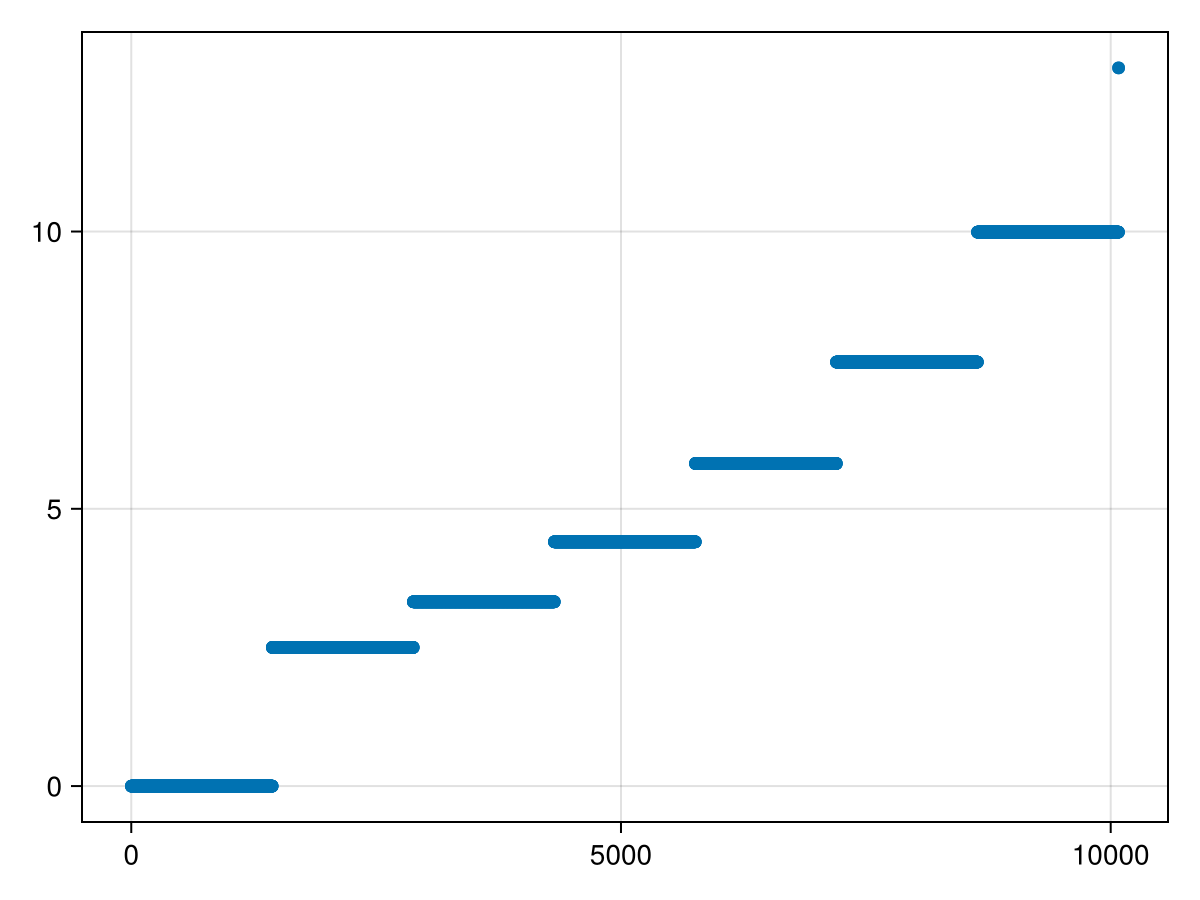

In [21]:
using CairoMakie

mean_df = combine(groupby(df, [:drug_conc]), [:Extinction_Time] => (x -> mean(x)) => :Mean)
mean_df.Mean .= mean_df.Mean ./ 24.0

fig = Figure()
ax = Axis(fig[1, 1], 
#limits = (nothing, nothing, 0, 15)
)
scatter!(ax, df.drug_conc[1])

fig

In [22]:
fig = Figure()

ax = Axis(fig[1, 1], 
yscale = log10)

ax2 = Axis(fig[1, 1], 
yaxisposition = :right)

CairoMakie.scatter!(ax, results.ResistantMetric.time, results.ResistantMetric.pop_focal .+ 1)
CairoMakie.scatter!(ax, results.ResistantMetric.time, results.ResistantMetric.pop_res .+ 1)
CairoMakie.lines!(ax2, results.ResistantMetric.time, results.ResistantMetric.drug_conc .+ 1, color = :red)

fig

UndefVarError: UndefVarError: `results` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [23]:
fig = Figure()

ax = Axis(fig[1, 1], 
limits = (0, 200, nothing, nothing))

CairoMakie.hist!(lin_survival_times(results.LineageSurvivalMetric), bins = 100)
CairoMakie.vlines!(ax, 24.0, color = :tomato, linestyle = :dash)

fig

UndefVarError: UndefVarError: `results` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [24]:
sum(results.LineageSurvivalMetric.alive)
#length(lin_survival_times(results.LineageSurvivalMetric))

UndefVarError: UndefVarError: `results` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [25]:
p_est(results.LineageSurvivalMetric) 

UndefVarError: UndefVarError: `results` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [26]:
0.21281702898553007

0.21281702898553007